# Atividade Prática: Criação de Máscaras Sintéticas, Anotação e Persistência de Dados

Versão com **importação de imagem própria** (upload) para gerar a máscara binária, em vez de criar a matriz do zero.

## 1. Importação da Imagem e Geração da Máscara Binária

Selecione a imagem que deseja importar:


Saving images.jpg to images.jpg
Imagem importada: 'images.jpg'
Imagem binária gerada: shape=(500, 500), dtype=uint8

Imagem binária (após threshold):


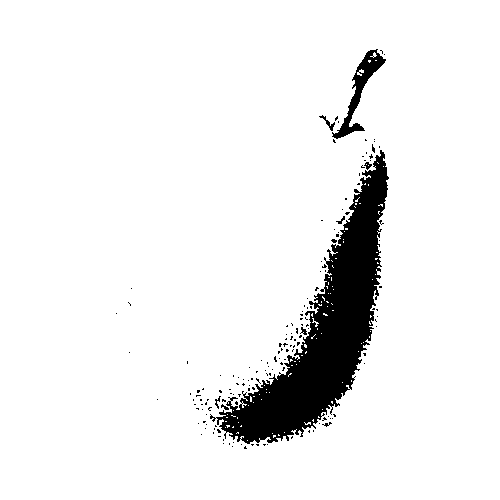

In [1]:
import numpy as np
import cv2
from google.colab import files
from google.colab.patches import cv2_imshow


print("Selecione a imagem que deseja importar:")
arquivos_enviados = files.upload()
nome_arquivo = list(arquivos_enviados.keys())[0]


imagem_original = cv2.imread(nome_arquivo, cv2.IMREAD_GRAYSCALE)

if imagem_original is None:
    raise ValueError("Não foi possível ler a imagem enviada. Verifique o formato do arquivo.")

altura, largura = 500, 500


imagem_redimensionada = cv2.resize(imagem_original, (largura, altura))

_, imagem_binaria = cv2.threshold(imagem_redimensionada, 127, 255, cv2.THRESH_BINARY)
imagem_binaria = imagem_binaria.astype(np.uint8)

print(f"Imagem importada: '{nome_arquivo}'")
print(f"Imagem binária gerada: shape={imagem_binaria.shape}, dtype={imagem_binaria.dtype}")

print("\nImagem binária (após threshold):")
cv2_imshow(imagem_binaria)

## 2. Desenho de Formas Geométricas e Texto

In [2]:
imagem_anotada = cv2.cvtColor(imagem_binaria, cv2.COLOR_GRAY2BGR)

tam_quadrado = 200
y0 = (altura - tam_quadrado) // 2
x0 = (largura - tam_quadrado) // 2
y1 = y0 + tam_quadrado
x1 = x0 + tam_quadrado

pt1_retangulo = (x0, y0)
pt2_retangulo = (x1, y1)
cor_retangulo = (0, 0, 255)
espessura_retangulo = 3

cv2.rectangle(imagem_anotada, pt1_retangulo, pt2_retangulo, cor_retangulo, espessura_retangulo)


centro_circulo = (largura // 2, altura // 2)
raio_circulo = 80
cor_circulo = (0, 255, 0)
espessura_circulo = 2

cv2.circle(imagem_anotada, centro_circulo, raio_circulo, cor_circulo, espessura_circulo)

texto = "MASCARA_01 - 500x500"
posicao_texto = (20, 30)
fonte = cv2.FONT_HERSHEY_SIMPLEX
escala_fonte = 0.7
cor_texto = (255, 255, 0)
espessura_texto = 2

cv2.putText(imagem_anotada, texto, posicao_texto, fonte, escala_fonte, cor_texto, espessura_texto)

print(f"Imagem anotada criada: shape={imagem_anotada.shape}, dtype={imagem_anotada.dtype}")

Imagem anotada criada: shape=(500, 500, 3), dtype=uint8


### Visualização das imagens

Imagem binária (a partir da imagem importada):


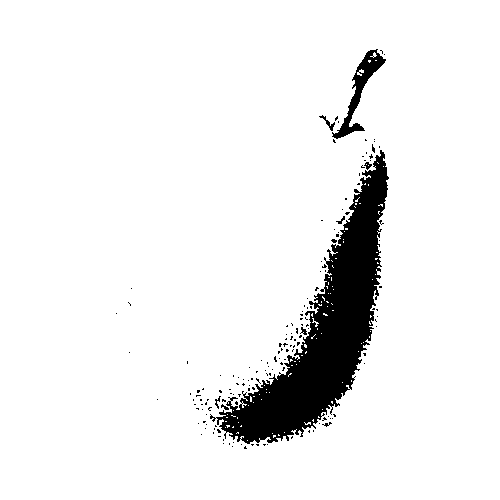


Imagem com formas e texto:


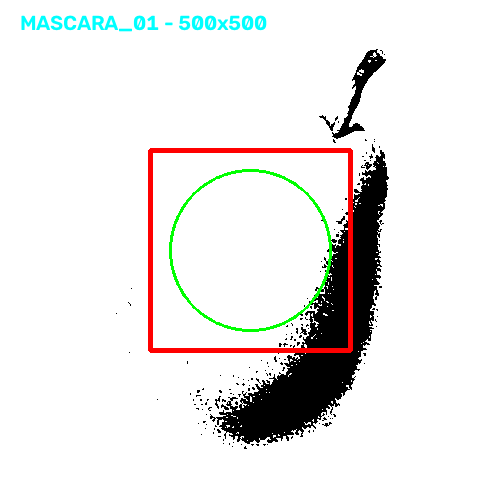

In [3]:
print("Imagem binária (a partir da imagem importada):")
cv2_imshow(imagem_binaria)

print("\nImagem com formas e texto:")
cv2_imshow(imagem_anotada)

## 3. Persistência e Leitura de Variáveis (.npz)

In [4]:
parametros_desenho = np.array([
    ("retangulo_pt1", pt1_retangulo),
    ("retangulo_pt2", pt2_retangulo),
    ("circulo_centro", centro_circulo),
    ("circulo_raio", (raio_circulo, raio_circulo)),
], dtype=object)

caminho_npz = "dados_mascara.npz"

np.savez_compressed(
    caminho_npz,
    imagem_binaria=imagem_binaria,
    imagem_anotada=imagem_anotada,
    parametros_desenho=parametros_desenho,
)

print(f"Arquivo '{caminho_npz}' salvo com sucesso.")

Arquivo 'dados_mascara.npz' salvo com sucesso.


### Rotina de carregamento para validação

In [5]:
dados_carregados = np.load(caminho_npz, allow_pickle=True)

print("Validação do arquivo .npz carregado:")
print(f"Chaves armazenadas: {dados_carregados.files}")

for chave in dados_carregados.files:
    array = dados_carregados[chave]
    print(f" - '{chave}': shape={array.shape}, dtype={array.dtype}")

Validação do arquivo .npz carregado:
Chaves armazenadas: ['imagem_binaria', 'imagem_anotada', 'parametros_desenho']
 - 'imagem_binaria': shape=(500, 500), dtype=uint8
 - 'imagem_anotada': shape=(500, 500, 3), dtype=uint8
 - 'parametros_desenho': shape=(4, 2), dtype=object


## 4. Exportação em Imagem (.jpg)

In [6]:
caminho_jpg = "resultado_anotado.jpg"
cv2.imwrite(caminho_jpg, imagem_anotada)

print(f"Imagem exportada com sucesso em '{caminho_jpg}'.")


Imagem exportada com sucesso em 'resultado_anotado.jpg'.
